# 📊 Social Audit Dataset Analysis using Python



<h2 style="text-align:center;font-weight:bold;color:#4C1D95;"> 📘 1. Project Introduction</h2>

##### The Social Audit is a powerful tool to ensure transparency, accountability, and citizen participation in government welfare schemes like MGNREGA.This project aims to analyze the Social Audit dataset to track financial misappropriation and recovery across different states and Gram Panchayats.

#### import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<h2 style="text-align:center;font-weight:bold;color:#4C1D95;"> PHASE 1 :DATA CLEANING & PREPROCESSING </h2>

#### import dataset

In [2]:


#df=pd.read_excel('C:\Users\psuni\Desktop\Social audit dataset for python.csv')
df=pd.read_csv(r'C:\Users\psuni\Desktop\Social audit dataset for python.csv')
print(df.shape)
df.head()

(2000, 20)


,State,District,GramPanchayat,AuditDate,FinancialYear,SchemeName,WorkType,AuditedBy,TotalExpenditure,MisappropriationAmount,RecoveryAmount,IssuesFound,IssueType,AuditStatus,BeneficiariesCovered,ManDaysGenerated,WagesPaid,MaterialCost,ComplaintsReceived,ActionTaken
0,Tamil Nadu,Chennai,GP_Chennai_34,18-11-2023,2021-22,PMGSY,School Building,SAU Team B,449857.43,109486.70,59286.30,1,Fund Diversion,Closed,63,4420,647742.72,521157.67,22,FIR Filed
1,Tamil Nadu,Chennai,GP_Chennai_40,27-06-2024,2023-24,NSAP,Pond Desilting,SAU Team B,923746.55,22216.64,20637.67,9,Wage Delay,Pending Recovery,365,2409,98301.41,23757.77,22,Warning Issued
2,Maharashtra,Mumbai,GP_Mumbai_76,30-05-2024,2021-22,NSAP,Toilet Construction,SAU Team A,286856.30,31249.04,71307.49,5,Incomplete Work,Completed,287,3742,99570.70,246425.59,21,No Action
3,Andhra Pradesh,Vizag,GP_Vizag_48,14-03-2024,2021-22,SBM-G,Road Construction,District Audit Unit,1709666.11,98793.38,78197.94,9,Fund Diversion,ATR Pending,392,7176,748214.61,520650.51,7,NaN
4,Maharashtra,Mumbai,GP_Mumbai_50,20-07-2024,2023-24,NSAP,Pond Desilting,SAU Team B,642423.90,137493.94,25496.21,4,Wage Delay,Pending Recovery,289,4085,889828.45,NaN,10,No Action




<h2 style="text-align:center;font-weight:bold;color:#4C1D95;"> 🎯 2. Project Objectives</h2>

##### 1. To clean and preprocess raw social audit data
##### 2. To identify and calculate Pending Recovery Amount (Misappropriation - Recovery)
##### 3. To detect inconsistencies and outliers in financial data
##### 4. To prepare data for Phase 2 - EDA and Visualization

#### Basic Explorations

In [3]:


print(f"Shape:{df.shape}")
print(f"Total cells:{df.size}")

print("\n")
## First and last 5 rows

print("============================================")
print(f"-----HEAD(first 5 rows)-------------")
print("============================================")
print(df.head())

print("\n")
print("============================================")
print(f"-----TAIL(Last 5 rows)-------------")
print("============================================")
print(df.tail())

Shape:(2000, 20)
Total cells:40000


-----HEAD(first 5 rows)-------------
            State District  GramPanchayat   AuditDate FinancialYear  \
0      Tamil Nadu  Chennai  GP_Chennai_34  18-11-2023       2021-22   
1      Tamil Nadu  Chennai  GP_Chennai_40  27-06-2024       2023-24   
2     Maharashtra   Mumbai   GP_Mumbai_76  30-05-2024       2021-22   
3  Andhra Pradesh    Vizag    GP_Vizag_48  14-03-2024       2021-22   
4     Maharashtra   Mumbai   GP_Mumbai_50  20-07-2024       2023-24   

  SchemeName             WorkType            AuditedBy  TotalExpenditure  \
0      PMGSY      School Building           SAU Team B         449857.43   
1       NSAP       Pond Desilting           SAU Team B         923746.55   
2       NSAP  Toilet Construction           SAU Team A         286856.30   
3      SBM-G    Road Construction  District Audit Unit        1709666.11   
4       NSAP       Pond Desilting           SAU Team B         642423.90   

   MisappropriationAmount  RecoveryAmount 

###


<h2 style="text-align:center;font-weight:bold;color:#4C1D95;">  📂 3. Dataset Overviews</h2>

##### Original: 2000 Rows x 21 Columns
##### After Cleaning: 1916 Rows x 20 Columns
##### Duplicates Removed: 84 Rows

In [4]:
## Datatypes
print("\n")
print("======================================================")
print("----------------------INFO----------------------------")
print("======================================================")
df.info()


print("\n")
print("==========================================================")
print("------------------------DESCRIPTION-----------------------")
print("==========================================================")
df.describe()



----------------------INFO----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2000 non-null   object 
 1   District                2000 non-null   object 
 2   GramPanchayat           2000 non-null   object 
 3   AuditDate               2000 non-null   object 
 4   FinancialYear           2000 non-null   object 
 5   SchemeName              2000 non-null   object 
 6   WorkType                2000 non-null   object 
 7   AuditedBy               2000 non-null   object 
 8   TotalExpenditure        2000 non-null   float64
 9   MisappropriationAmount  1801 non-null   float64
 10  RecoveryAmount          1804 non-null   float64
 11  IssuesFound             2000 non-null   int64  
 12  IssueType               1792 non-null   object 
 13  AuditStatus             2000 non-nul

,TotalExpenditure,MisappropriationAmount,RecoveryAmount,IssuesFound,BeneficiariesCovered,ManDaysGenerated,WagesPaid,MaterialCost,ComplaintsReceived
count,2.000000e+03,1801.000000,1804.000000,2000.000000,2000.000000,2000.000000,2000.000000,1805.000000,2000.000000
mean,1.033106e+06,76446.711094,40077.605610,5.514500,252.821500,4058.730500,515555.986460,404413.396753,12.165500
std,5.600802e+05,43251.696237,22980.853537,3.491545,144.072465,2287.049609,281383.512293,225807.526839,7.179476
min,5.036113e+04,17.800000,19.250000,0.000000,10.000000,100.000000,20499.790000,10087.080000,0.000000
25%,5.664719e+05,38510.670000,20384.472500,3.000000,124.000000,2097.750000,268687.360000,212191.780000,6.000000
50%,1.030536e+06,78164.430000,39976.170000,5.000000,257.000000,4077.000000,513757.790000,404937.610000,12.000000
75%,1.508291e+06,113763.710000,59249.452500,9.000000,376.250000,6030.000000,758425.725000,590883.880000,18.000000
max,1.999289e+06,149972.510000,79991.410000,11.000000,499.000000,7998.000000,998816.990000,799428.460000,24.000000


####  Checking for Unique Values

In [5]:

print("\n")
print("=====================================================================")
print("                       STATE LIST                         ")
print("=====================================================================")
print(df['State'].unique())
print(f"Total States:{df['State'].nunique()}")
#print("\n")

print("\n")
print("==========================================================")
print("                       SCHEME NAME LIST                   ")
print("==========================================================")
print(df['SchemeName'].unique())
print(f"Total Schemes:{df['SchemeName'].nunique()}")
print("\n")
print(df['SchemeName'].value_counts())
print("\n")

#print("\n")
print("==========================================================")
print("                       WORK TYPE LIST                   ")
print("==========================================================")
print(df['WorkType'].unique())
print(f"Total Worktypes:{df['WorkType'].nunique()}")
print("\n")
print(df['WorkType'].value_counts())
print("\n")

print("==========================================================")
print("                       ISSUE TYPE LIST                   ")
print("==========================================================")
print(df['IssueType'].unique())
print(f"Total issue types:{df['IssueType'].nunique()}")
print("\n")
print(df['IssueType'].value_counts())

print("\n")
print("==========================================================")
print("                       AUDIT STATUS                       ")
print("==========================================================")
print(df['AuditStatus'].value_counts())
print("\n")

print("==========================================================")
print("                       AUDITED BY                        ")
print("==========================================================")
print(df['AuditedBy'].value_counts())
print("\n")

print("==========================================================")
print("                      FINANCIAL YEAR                      ")
print("==========================================================")
print(df['FinancialYear'].value_counts())
print("\n")



                       STATE LIST                         
['Tamil Nadu' 'Maharashtra' 'Andhra Pradesh' 'Rajasthan' 'Karnataka'
 'Uttar Pradesh' 'Bihar' 'Kerala']
Total States:8


                       SCHEME NAME LIST                   
['PMGSY' 'NSAP' 'SBM-G' 'PMAY-G' 'MGNREGA']
Total Schemes:5


SchemeName
PMAY-G     439
MGNREGA    398
NSAP       392
SBM-G      386
PMGSY      385
Name: count, dtype: int64


                       WORK TYPE LIST                   
['School Building' 'Pond Desilting' 'Toilet Construction'
 'Road Construction' 'Water Tank']
Total Worktypes:5


WorkType
Road Construction      420
Pond Desilting         411
School Building        406
Water Tank             390
Toilet Construction    373
Name: count, dtype: int64


                       ISSUE TYPE LIST                   
['Fund Diversion' 'Wage Delay' 'Incomplete Work' 'Ghost Beneficiary'
 'Material Overbilling' nan 'No Muster Roll']
Total issue types:6


IssueType
Wage Delay              311
Incomple

In [6]:
# ============ Correction of  NaN ============

#  having columns with Numbers   fill with 0 
df['MisappropriationAmount'] = df['MisappropriationAmount'].fillna(0)
df['RecoveryAmount'] = df['RecoveryAmount'].fillna(0)
df['MaterialCost'] = df['MaterialCost'].fillna(0)

#   having columns with Text   fill with  Default text
df['IssueType'] = df['IssueType'].fillna('Not Reported')
df['ActionTaken'] = df['ActionTaken'].fillna('No Action Taken')

# ============ Correction of Datatype ============

# convert 'AuditDate' datatype  object to Date type 
df['AuditDate'] = pd.to_datetime(df['AuditDate'], dayfirst=True, errors='coerce')

print("\n")
print("==========================================================")
print("                       AFTER CORRECTION                   ")
print("==========================================================")
df.info()
print("\nNulls:", df.isnull().sum().sum())



                       AFTER CORRECTION                   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   State                   2000 non-null   object        
 1   District                2000 non-null   object        
 2   GramPanchayat           2000 non-null   object        
 3   AuditDate               2000 non-null   datetime64[ns]
 4   FinancialYear           2000 non-null   object        
 5   SchemeName              2000 non-null   object        
 6   WorkType                2000 non-null   object        
 7   AuditedBy               2000 non-null   object        
 8   TotalExpenditure        2000 non-null   float64       
 9   MisappropriationAmount  2000 non-null   float64       
 10  RecoveryAmount          2000 non-null   float64       
 11  IssuesFound             2000 non-null   int64  

In [7]:
# ============ COLUMN RENAME - CLEANING ============

# PROPER
df.rename(columns={
    'State': 'State',
    'District': 'District',
    'GramPanchayat': 'Gram_Panchayat',
    'AuditDate': 'Audit_Date',
    'FinancialYear': 'Financial_Year',
    'SchemeName': 'Scheme_Name',
    'WorkType': 'Work_Type',
    'AuditedBy': 'Audited_By',
    'TotalExpenditure': 'Total_Expenditure',
    'MisappropriationAmount': 'Misappropriation_Amount',
    'RecoveryAmount': 'Recovery_Amount',
    'IssuesFound': 'Issues_Found',
    'IssueType': 'Issue_Type',
    'AuditStatus': 'Audit_Status',
    'BeneficiariesCovered': 'Beneficiaries_Covered',
    'ManDaysGenerated': 'Man_Days_Generated',
    'WagesPaid': 'Wages_Paid',
    'MaterialCost': 'Material_Cost',
    'ComplaintsReceived': 'Complaints_Received',
    'ActionTaken': 'Action_Taken'
}, inplace=True)

# After cleaning
print("\n")
print("==========================================================")
print("                       AFTER CORRECTION                   ")
print("==========================================================")
print(df.columns.tolist())
print("\n")
df.head(2)



                       AFTER CORRECTION                   
['State', 'District', 'Gram_Panchayat', 'Audit_Date', 'Financial_Year', 'Scheme_Name', 'Work_Type', 'Audited_By', 'Total_Expenditure', 'Misappropriation_Amount', 'Recovery_Amount', 'Issues_Found', 'Issue_Type', 'Audit_Status', 'Beneficiaries_Covered', 'Man_Days_Generated', 'Wages_Paid', 'Material_Cost', 'Complaints_Received', 'Action_Taken']




,State,District,Gram_Panchayat,Audit_Date,Financial_Year,Scheme_Name,Work_Type,Audited_By,Total_Expenditure,Misappropriation_Amount,Recovery_Amount,Issues_Found,Issue_Type,Audit_Status,Beneficiaries_Covered,Man_Days_Generated,Wages_Paid,Material_Cost,Complaints_Received,Action_Taken
0,Tamil Nadu,Chennai,GP_Chennai_34,2023-11-18,2021-22,PMGSY,School Building,SAU Team B,449857.43,109486.70,59286.30,1,Fund Diversion,Closed,63,4420,647742.72,521157.67,22,FIR Filed
1,Tamil Nadu,Chennai,GP_Chennai_40,2024-06-27,2023-24,NSAP,Pond Desilting,SAU Team B,923746.55,22216.64,20637.67,9,Wage Delay,Pending Recovery,365,2409,98301.41,23757.77,22,Warning Issued


In [8]:
print("\n")
print("======================================================")
print("----------------------INFO----------------------------")
print("======================================================")
df.info()


print("\n")
print("==========================================================")
print("------------------------DESCRIPTION-----------------------")
print("==========================================================")
df.describe()



----------------------INFO----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   State                    2000 non-null   object        
 1   District                 2000 non-null   object        
 2   Gram_Panchayat           2000 non-null   object        
 3   Audit_Date               2000 non-null   datetime64[ns]
 4   Financial_Year           2000 non-null   object        
 5   Scheme_Name              2000 non-null   object        
 6   Work_Type                2000 non-null   object        
 7   Audited_By               2000 non-null   object        
 8   Total_Expenditure        2000 non-null   float64       
 9   Misappropriation_Amount  2000 non-null   float64       
 10  Recovery_Amount          2000 non-null   float64       
 11  Issues_Found             2000 non-null

,Audit_Date,Total_Expenditure,Misappropriation_Amount,Recovery_Amount,Issues_Found,Beneficiaries_Covered,Man_Days_Generated,Wages_Paid,Material_Cost,Complaints_Received
count,2000,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2023-05-29 00:40:19.200000,1.033106e+06,68840.263340,36150.000260,5.514500,252.821500,4058.730500,515555.986460,364983.090570,12.165500
min,2022-01-01 00:00:00,5.036113e+04,0.000000,0.000000,0.000000,10.000000,100.000000,20499.790000,0.000000,0.000000
25%,2022-09-17 00:00:00,5.664719e+05,26527.172500,14011.082500,3.000000,124.000000,2097.750000,268687.360000,146932.847500,6.000000
50%,2023-05-26 00:00:00,1.030536e+06,68031.715000,35480.705000,5.000000,257.000000,4077.000000,513757.790000,360964.000000,12.000000
75%,2024-02-15 06:00:00,1.508291e+06,109508.007500,56923.072500,9.000000,376.250000,6030.000000,758425.725000,572844.527500,18.000000
max,2024-09-26 00:00:00,1.999289e+06,149972.510000,79991.410000,11.000000,499.000000,7998.000000,998816.990000,799428.460000,24.000000
std,NaN,5.600802e+05,46993.322475,24867.488337,3.491545,144.072465,2287.049609,281383.512293,245792.016161,7.179476


In [9]:
# ============HANDLING DUPLICATE VALUES  ============

print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")

# REMOVING DUPLICATES
df.drop_duplicates(inplace=True)

print(f"After removing duplicates: {len(df)} rows")


print("\n")
print("==========================================================")
print(f"                   CLEANED DATASET                        ")
print("==========================================================")


df.info()

Total rows: 2000
Duplicate rows: 84
After removing duplicates: 1916 rows


                   CLEANED DATASET                        
<class 'pandas.core.frame.DataFrame'>
Index: 1916 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   State                    1916 non-null   object        
 1   District                 1916 non-null   object        
 2   Gram_Panchayat           1916 non-null   object        
 3   Audit_Date               1916 non-null   datetime64[ns]
 4   Financial_Year           1916 non-null   object        
 5   Scheme_Name              1916 non-null   object        
 6   Work_Type                1916 non-null   object        
 7   Audited_By               1916 non-null   object        
 8   Total_Expenditure        1916 non-null   float64       
 9   Misappropriation_Amount  1916 non-null   float64       
 10  Recovery_Amount          19

In [10]:
# REMOVING UNWANTED COLUMNS#

# Audit_Date column is reduntant data and we can do our insights using financial year,so dropping audit_Date #

df.drop(columns=['Audit_Date'],inplace=True)

print("\n")


In [11]:

print("==========================================================")
print(f"                   CLEANED DATASET                        ")
print("==========================================================")
df.info()

                   CLEANED DATASET                        
<class 'pandas.core.frame.DataFrame'>
Index: 1916 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    1916 non-null   object 
 1   District                 1916 non-null   object 
 2   Gram_Panchayat           1916 non-null   object 
 3   Financial_Year           1916 non-null   object 
 4   Scheme_Name              1916 non-null   object 
 5   Work_Type                1916 non-null   object 
 6   Audited_By               1916 non-null   object 
 7   Total_Expenditure        1916 non-null   float64
 8   Misappropriation_Amount  1916 non-null   float64
 9   Recovery_Amount          1916 non-null   float64
 10  Issues_Found             1916 non-null   int64  
 11  Issue_Type               1916 non-null   object 
 12  Audit_Status             1916 non-null   object 
 13  Beneficiaries_Covered   

In [12]:
# ADDING CALCULATED COLUMN 

#Pending_Recovery_amt=missappropriation_amt-  Recovery amount

df['Pending_Recovery'] = df['Misappropriation_Amount'] - df['Recovery_Amount']

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1916 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    1916 non-null   object 
 1   District                 1916 non-null   object 
 2   Gram_Panchayat           1916 non-null   object 
 3   Financial_Year           1916 non-null   object 
 4   Scheme_Name              1916 non-null   object 
 5   Work_Type                1916 non-null   object 
 6   Audited_By               1916 non-null   object 
 7   Total_Expenditure        1916 non-null   float64
 8   Misappropriation_Amount  1916 non-null   float64
 9   Recovery_Amount          1916 non-null   float64
 10  Issues_Found             1916 non-null   int64  
 11  Issue_Type               1916 non-null   object 
 12  Audit_Status             1916 non-null   object 
 13  Beneficiaries_Covered    1916 non-null   int64  
 14  Man_Days_Generated       1916

#### Checked for inconsistencies using unique() on above, found that all values in the dataset are standardized


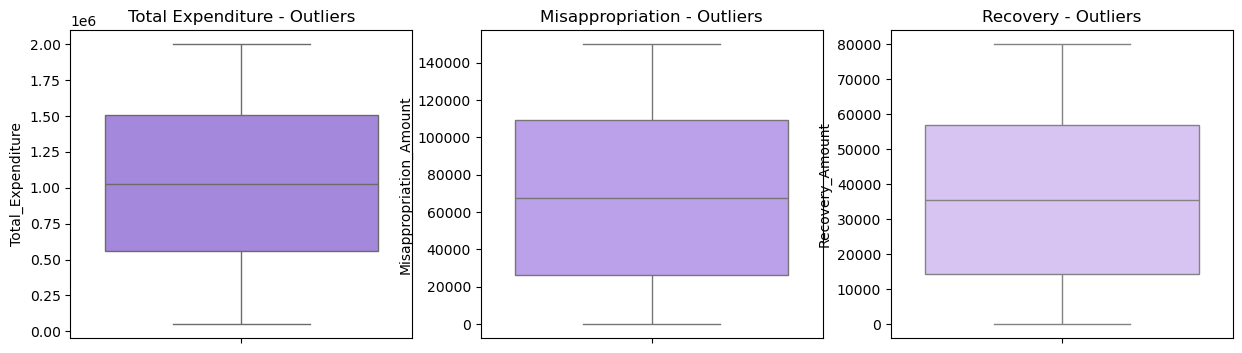

Outliers found: 0


In [13]:
# Outlier Detection - Box Plot

plt.figure(figsize=(15,4))

lavender_colors=['#9F7AEA','#B794F6','#D6BCFA']

plt.subplot(1,3,1)
sns.boxplot(y=df['Total_Expenditure'],color=lavender_colors[0])
plt.title('Total Expenditure - Outliers')

plt.subplot(1,3,2)
sns.boxplot(y=df['Misappropriation_Amount'],color=lavender_colors[1])
plt.title('Misappropriation - Outliers')

plt.subplot(1,3,3)
sns.boxplot(y=df['Recovery_Amount'],color=lavender_colors[2])
plt.title('Recovery - Outliers')

plt.show()

# Outlier Count Check using IQR
Q1 = df['Misappropriation_Amount'].quantile(0.25)
Q3 = df['Misappropriation_Amount'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Misappropriation_Amount'] < Q1-1.5*IQR) | (df['Misappropriation_Amount'] > Q3+1.5*IQR)]
print(f"Outliers found: {len(outliers)}")

### 4. Phase 1 - Data Cleaning Steps 

##### Checked shape, info, null values, duplicates (84 found)
##### Removed duplicates -> 1916 rows
##### Dropped Audit_Date column (not needed for analysis)
##### Added Pending_Recovery column for analysis
##### Checked inconsistencies using unique() - all values standardized
##### Outlier Checking using Boxplot
##### Final Dataset: 1916 entries, 20 columns, 0 null values 

<h2 style="text-align:center;font-weight:bold;color:#4C1D95;"> PHASE 2 :EDA & Visualizations </h2> 

#### Univariate, bivariate, and multivariate analysis

--- UNIVARIATE ANALYSIS ---
count      1916.000000
mean      68748.789259
std       46983.422890
min           0.000000
25%       26527.172500
50%       67696.775000
75%      109343.937500
max      149972.510000
Name: Misappropriation_Amount, dtype: float64

Audit Status Count:
 Audit_Status
Under Review        405
Closed              400
ATR Pending         400
Pending Recovery    365
Completed           346
Name: count, dtype: int64


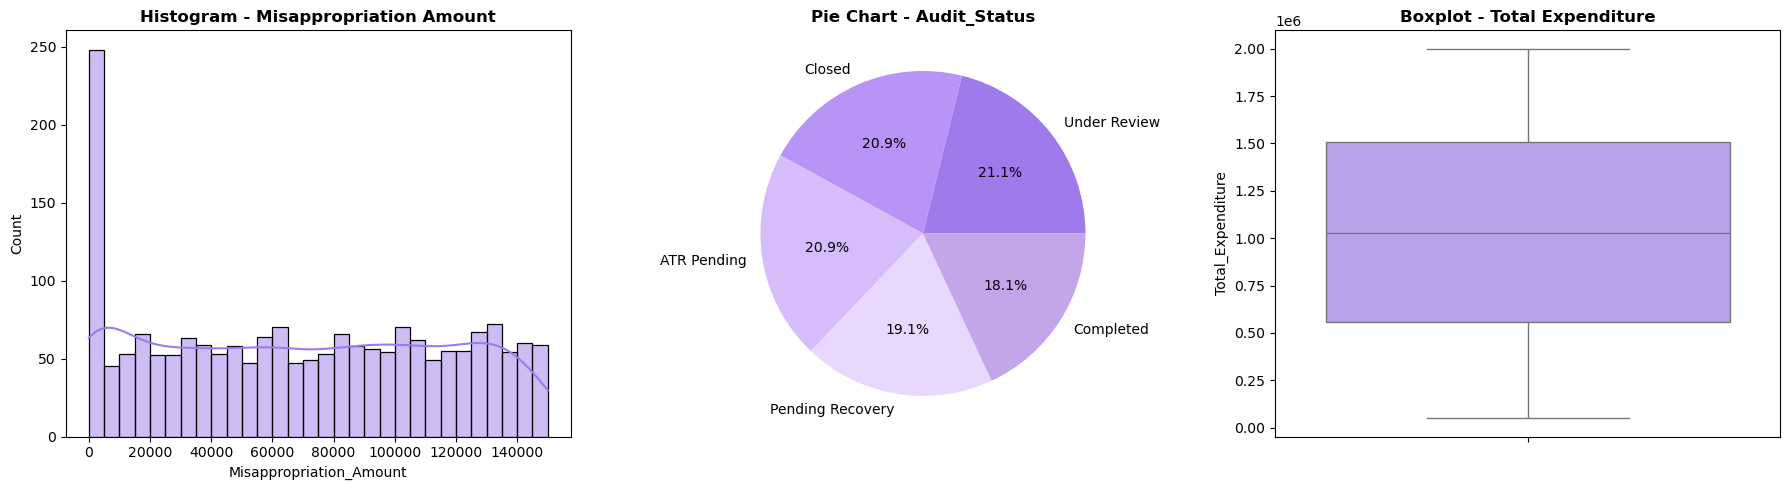

In [14]:
# UNIVARIATE ANALYSIS - Single column analysis
print("--- UNIVARIATE ANALYSIS ---")
print(df['Misappropriation_Amount'].describe())
print("\nAudit Status Count:\n", df['Audit_Status'].value_counts())

# Histogram + Pie + Box in Subplots
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Lavender palette
lavender_colors = ['#9F7AEA', '#B794F6', '#D6BCFA', '#E9D8FD', '#C3A6E8']
pie_colors = ['#9F7AEA', '#B794F6', '#D6BCFA', '#E9D8FD', '#C3A6E8']

# Histogram
sns.histplot(df['Misappropriation_Amount'], bins=30, kde=True, ax=axes[0], color=lavender_colors[0])
axes[0].set_title('Histogram - Misappropriation Amount', fontweight='bold')

# Pie Chart - Recovery Status
df['Audit_Status'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=pie_colors)
axes[1].set_title('Pie Chart - Audit_Status', fontweight='bold')
axes[1].set_ylabel('')

# Box Plot
sns.boxplot(y=df['Total_Expenditure'], ax=axes[2], color=lavender_colors[1])
axes[2].set_title('Boxplot - Total Expenditure', fontweight='bold')

plt.tight_layout()
plt.show()

For above UNIVARIATE ANALYSIS  Selected 
 categorical column --> misappropriation_amount for statistical summary and histogram
  numerical_coumn --> audit_status for count and pie chart 
  and one expenditure column for boxplot to check distribution and outliers, then the result is:
 

### Misappropriation Amount - Insights from chart

The analysis of 1916 cases shows the minimum misappropriation is ₹0 and maximum is ₹1,49,972 with mean ₹68,748 and median ₹67,696 (Q1: ₹26,527, Q3:
₹1,09,343). The histogram shows a high peak at ₹0-₹5,000 range with approximately 240 cases, but distribution is uniform from ₹20,000 to ₹1,40,000. This indicates misappropriation occurs across all amount levels, not only in small amounts, requiring monitoring of both low and high-value works

### Audit_Status - Insight from chart

Out of 1916 cases, Under Review is highest at 21.1% (405 cases), followed by Closed 20.9% (400 cases) and ATR Pending 20.9% (400 cases). Pending Recovery accounts for 19.1% (365 cases) and Completed is lowest at 18.1% (346 cases). This shows only 18.1% audits are fully completed, while 62.1% cases are still pending in Under Review, ATR Pending and Pending Recovery stages, indicating slow audit closure and need for faster follow-up action

### Total_Expenditure (Boxplot) - Insight from chart:

The boxplot shows median expenditure is approximately ₹1.0 Lakh. 50% of works have expenditure between ₹0.55 Lakhs (Q1) and ₹1.45 Lakhs (Q3). The range extends from near 0 to ₹2.0 Lakhs with no major outliers, indicating expenditure is fairly distributed. Very low values near 0 may require verification for data entry errors or incomplete works.

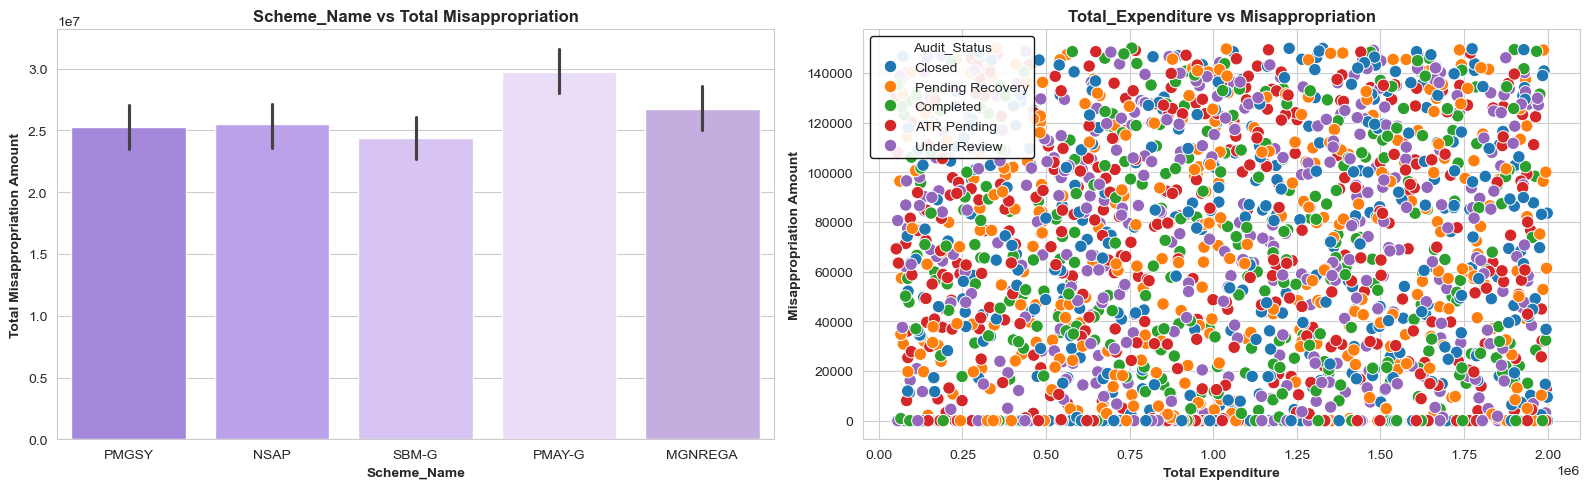

In [48]:
# BIVARIATE ANALYSIS - 2 Variables Relationship
fig, axes = plt.subplots(1, 2, figsize=(16,5))

# Lavender palette
lavender_colors = ['#9F7AEA', '#B794F6', '#D6BCFA', '#E9D8FD', '#C3A6E8']
scatter_lavender=['#6D28D9','#8B5CF6','#A76BFA','#C4B5FD','#DDD6FE']

# 1. BARPLOT - Scheme_Name vs Misappropriation_Amount
sns.barplot(x='Scheme_Name', y='Misappropriation_Amount', data=df, estimator=sum,hue='Scheme_Name',legend=False, ax=axes[0], palette=lavender_colors)
axes[0].set_title('Scheme_Name vs Total Misappropriation', fontweight='bold')
axes[0].tick_params(axis='x')
axes[0].set_xlabel('Scheme_Name', fontweight='bold')
axes[0].set_ylabel('Total Misappropriation Amount', fontweight='bold')

 #2. SCATTER PLOT - Total_Expenditure vs Misappropriation_Amount
sns.scatterplot(x='Total_Expenditure', y='Misappropriation_Amount', hue='Audit_Status', data=df, ax=axes[1], s=80,
                #palette=scatter_lavender)
palette=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'])
axes[1].set_title('Total_Expenditure vs Misappropriation', fontweight='bold')
axes[1].set_xlabel('Total Expenditure', fontweight='bold')
axes[1].set_ylabel('Misappropriation Amount', fontweight='bold')

axes[1].legend(title='Audit_Status',loc='upper left',frameon=True,facecolor='white',edgecolor='black',framealpha=0.9)

plt.tight_layout()
plt.show()

#### 1. Scheme_Name vs Total Misappropriation (Barplot) -Insights 
PMAY-G scheme shows highest total misappropriation of approx ₹2.95 Crores (2.95e7), followed by MGNREGA ₹2.65 Crores. PMGSY is ₹2.50 Cr, NSAP is ₹2.53 Cr, and SBM-G is lowest at ₹2.42 Cr. This indicates PMAY-G housing scheme is most vulnerable to financial irregularities and needs strict social audit focus.

#### 2. Total_Expenditure vs Misappropriation (Scatter Plot) -Insights
Scatter plot between Total Expenditure (0 to 2 Lakhs) and Misappropriation Amount (0 to 1,50,000) shows random distribution with no correlation. All Audit_Status types - Closed, Pending Recovery, Completed, ATR Pending, Under Review - are mixed uniformly. This proves misappropriation is independent of total expenditure; fraud occurs at all expenditure levels and audit status does not depend on amount spent.

#### Conclusion: PMAY-G has highest total fraud, and there is no correlation between expenditure and misappropriation

In [49]:
# MULTIVARIATE, GROUPBY, PIVOT TABLE, CORRELATION

# Groupby Analysis
district_group = df.groupby('District')['Misappropriation_Amount'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
print("Groupby - District wise Misappropriation:\n", district_group.head(10))



Groupby - District wise Misappropriation:
                    sum          mean  count
District                                   
Udaipur     8954404.11  75884.780593    118
Coimbatore  8890970.09  68392.077615    130
Gaya        8889569.87  77300.607565    115
Bangalore   8880848.31  79293.288482    112
Thrissur    8880634.52  71045.076160    125
Chennai     8861660.58  66629.026917    133
Pune        8750448.94  69448.007460    126
Mysore      8618270.06  67860.394173    127
Patna       7942764.96  66189.708000    120
Mumbai      7936004.04  69008.730783    115


Insights from Multivariate Analysis:

1. Groupby Analysis (District-wise Misappropriation)
- Udaipur has the highest total misappropriation amount with ₹89,54,404.11 (118 cases), followed closely by Coimbatore and Gaya.
- Chennai has the highest number of fraud cases (133 cases) but its average fraud amount (₹66,629) is comparatively low, indicating frequent but 
   small-scale frauds.
- Gaya has the highest average fraud per case (₹77,300) which indicates high-value frauds.
- The distribution of fraud is almost uniform across districts, with all top 8 districts ranging between 86L - 89L.

In [18]:
# Pivot Table
pivot = pd.pivot_table(df, values='Misappropriation_Amount', index='District', columns='Audit_Status', aggfunc='sum', fill_value=0)
print("\nPivot Table - District vs audit_Status:\n", pivot.head())




Pivot Table - District vs audit_Status:
 Audit_Status  ATR Pending      Closed   Completed  Pending Recovery  \
District                                                              
Bangalore      2003847.60  2065722.34  1909369.32        1534992.42   
Chennai        2005047.35  2077529.97  1283685.28        1536335.43   
Coimbatore     2693030.89  1512634.98  2069589.57        1526260.22   
Ernakulam      1218465.38  1078565.07  1828241.66        1772242.67   
Gaya           1894703.53  1564298.11  1264619.67        2068435.26   

Audit_Status  Under Review  
District                    
Bangalore       1366916.63  
Chennai         1959062.55  
Coimbatore      1089454.43  
Ernakulam        956565.78  
Gaya            2097513.30  


2. Pivot Table Analysis (District vs Audit_Status):
- The pivot table shows that misappropriation amounts are distributed across all Audit Status categories like Closed, completed, Under Review,
   ATR Pending.
- This proves that audit status is independent of the district and fraud is not concentrated in a single audit stage.

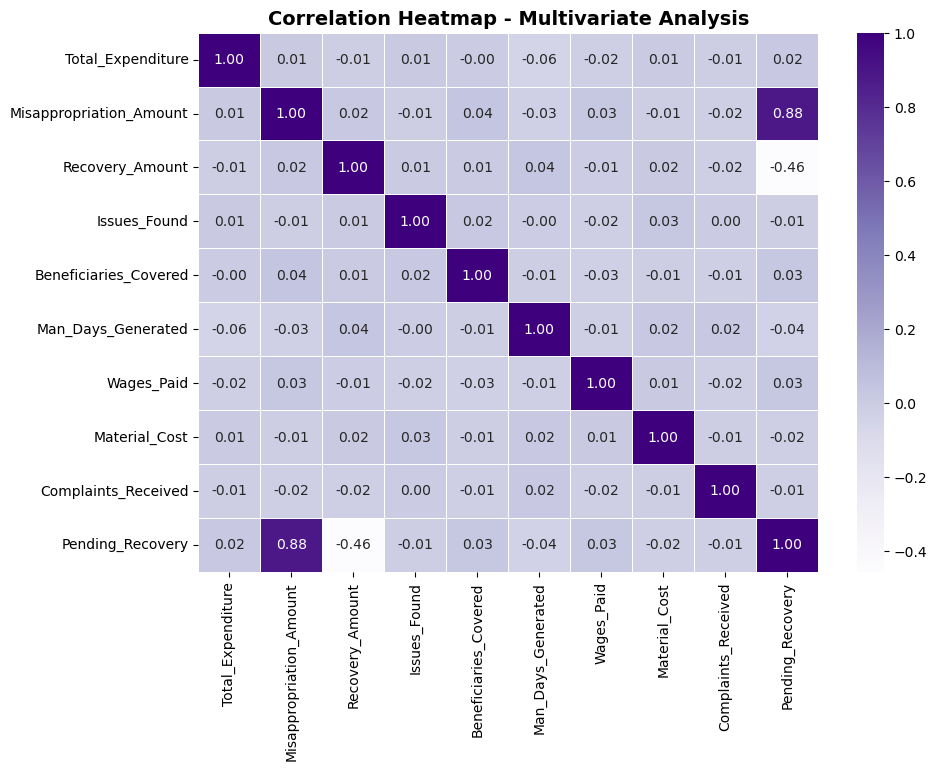

In [19]:
# Correlation Analysis
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='Purples', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Multivariate Analysis', fontweight='bold', fontsize=14)
plt.show()


3. Correlation Analysis (Multivariate):
- The correlation heatmap shows very low/near-zero correlation between Total_Expenditure and Misappropriation_Amount.
- This confirms that the amount of fraud does "NOT depend" on how much money was spent. Fraud is happening at all levels of expenditure.

Final Conclusion: Udaipur is the most vulnerable district in terms of total fraud value, and there is no relationship between total expenditure 
    and misappropriation, suggesting systemic issues rather than budget-size issues.

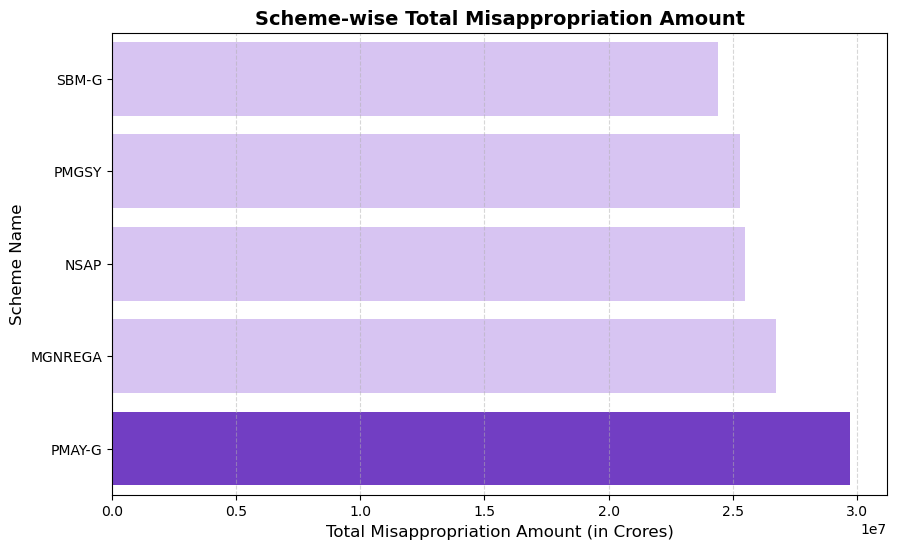

In [20]:
# BAR PLOT - Scheme vs Total Missappropriation

plt.figure(figsize=(10,6))

 #Lavender shades - PMAY-G dark, others light to medium
colors = ['#D6BCFA', '#D6BCFA', '#C3A6E8', '#B794F6', '#9F7AEA'] 

# Groupby - Scheme wise total fraud
scheme_fraud = df.groupby('Scheme_Name')['Misappropriation_Amount'].sum().sort_values(ascending=True)

# Create color list - all lavender except highest is dark purple
lavender_light = '#D6BCFA'  # light lavender for others
dark_purple = '#6D28D9'     # dark royal purple for highest

colors = [lavender_light] * (len(scheme_fraud)-1) + [dark_purple]
# Last one is highest because sort_values ascending

#colors = ['#FF6B6B' if x == scheme_fraud.idxmax() else '#4ECDC4' for x in scheme_fraud.index]

sns.barplot(x=scheme_fraud.values, y=scheme_fraud.index,hue=scheme_fraud.index,legend=False, palette=colors)

plt.title('Scheme-wise Total Misappropriation Amount', fontweight='bold', fontsize=14)
plt.xlabel('Total Misappropriation Amount (in Crores)', fontsize=12)
plt.ylabel('Scheme Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

#### Insights from Bar Plot:

PMAY-G has highest total misappropriation (~2.9 cr), it needs a strict audit and systematic followups and very bold decisions when failure occurs.

Audit_Status
Under Review        405
Closed              400
ATR Pending         400
Pending Recovery    365
Completed           346
Name: count, dtype: int64


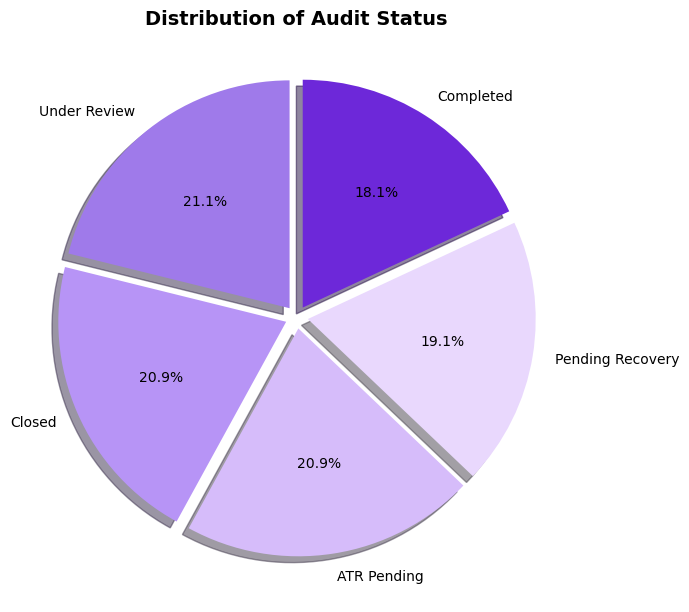

In [21]:
# PIE CHART 

plt.figure(figsize=(7,7))

status_count = df['Audit_Status'].value_counts()
print(status_count)

explode = [0.05]*len(status_count)

#Lavender palette - 5 shades for 5 Audit Status
lavender_pie = ['#9F7AEA', '#B794F6', '#D6BCFA', '#E9D8FD','#6D28D9']

plt.pie(status_count.values, labels=status_count.index, autopct='%1.1f%%', 
        startangle=90, shadow=True, explode=explode,colors=lavender_pie)

plt.title('Distribution of Audit Status', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#### INSIGHTS FROM Pie chart shows  audit status distribution is almost balanced. Under reviwe 21.1% highest, completed 18.1% which is the lowest. Almost every audit status is ~20% around, so no bias in this data.

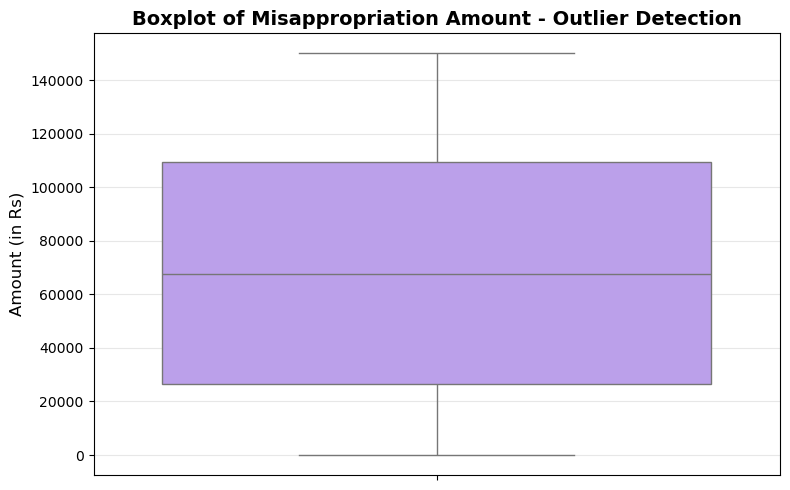

In [23]:
# BOX PLOT - Overall

plt.figure(figsize=(8,5))

sns.boxplot(y=df['Misappropriation_Amount'], color='#B794F6')

plt.title('Boxplot of Misappropriation Amount - Outlier Detection', fontweight='bold', fontsize=14)
plt.ylabel('Amount (in Rs)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### INSIGHTS FROM BOXPLOT : OVERALL ==>Overall Boxplot shows a median misappropriation is around 68k, and there are no outliers, which indicates that data is consistent there is no fraud case beyond 1.5L. This means misappropriation is spread evenly.

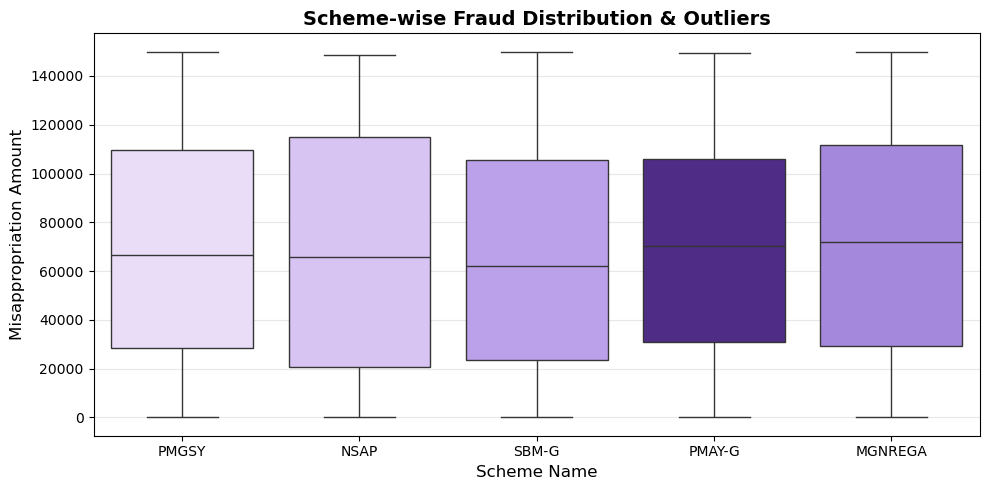

In [24]:
# BOX PLOT - Scheme wise

plt.figure(figsize=(10,5))


#mapping - PMAY-G = highest =
contrast_lavender = {
'PMGSY': '#E9D8FD', # lightest - lowest fraud
'NSAP': '#D6BCFA',
'SBM-G': '#B794F6',
'MGNREGA': '#9F7AEA','PMAY-G':'#4C1D95'}
#Highest = darkest, Lowest = lightest - full contrast
#high_contrast_lavender = ['#E9D8FD', '#D6BCFA', '#B794F6','#9F7AEA','#4C1D95'] 
# Order: lightest -> darkest

sns.boxplot(x='Scheme_Name', y='Misappropriation_Amount', data=df, hue='Scheme_Name',legend=False,palette=contrast_lavender)

plt.title('Scheme-wise Fraud Distribution & Outliers', fontweight='bold',fontsize=14)
plt.xlabel('Scheme Name', fontsize=12)
plt.ylabel('Misappropriation Amount', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### INSIGHTS FROM BOXPLOT2 : Scheme wise ==> Here Bloxplot shows no extreme outliers, data is within 0-1.4 L.All 5 schemes have similar median misappropriation around 60K, but NSAP has widest variation.

### Year-wise Fraud Trend - Using Line chart

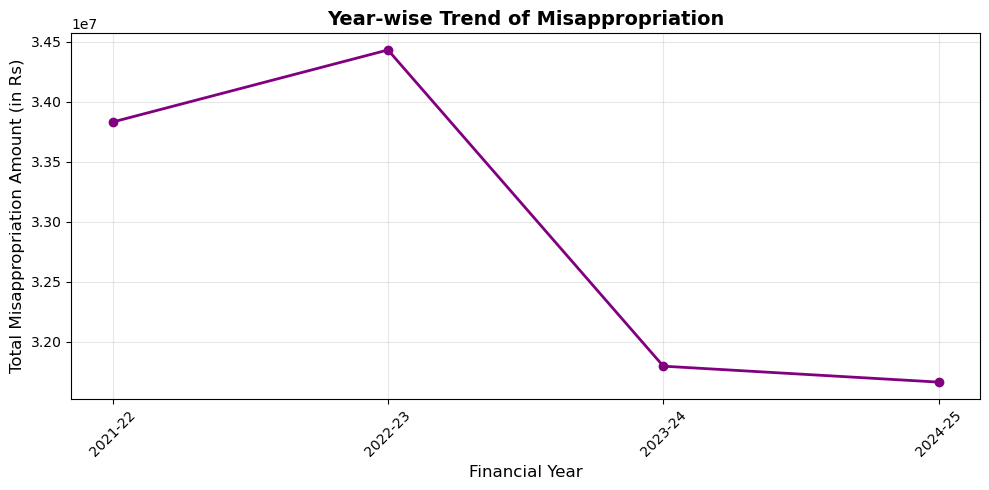

In [25]:
# LINE CHART - 

yearly_fraud = df.groupby('Financial_Year')['Misappropriation_Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_fraud.index, yearly_fraud.values, marker='o', color='purple', linewidth=2, linestyle='-')

plt.title('Year-wise Trend of Misappropriation', fontweight='bold', fontsize=14)
plt.xlabel('Financial Year', fontsize=12)
plt.ylabel('Total Misappropriation Amount (in Rs)', fontsize=12)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### line chart shows year-wise trend of total misappropriation. The highest fraud was in 2022-23 with about 3.44 crores. After that, there is a sharp decline to 3.19 crores in 2023-24, showing the effectiveness of social audits. In 2024-25 it remained stable around 3.18 crores. So overall, misappropriation is now under control and decreasing.

###  No.of Complaint VS  State 

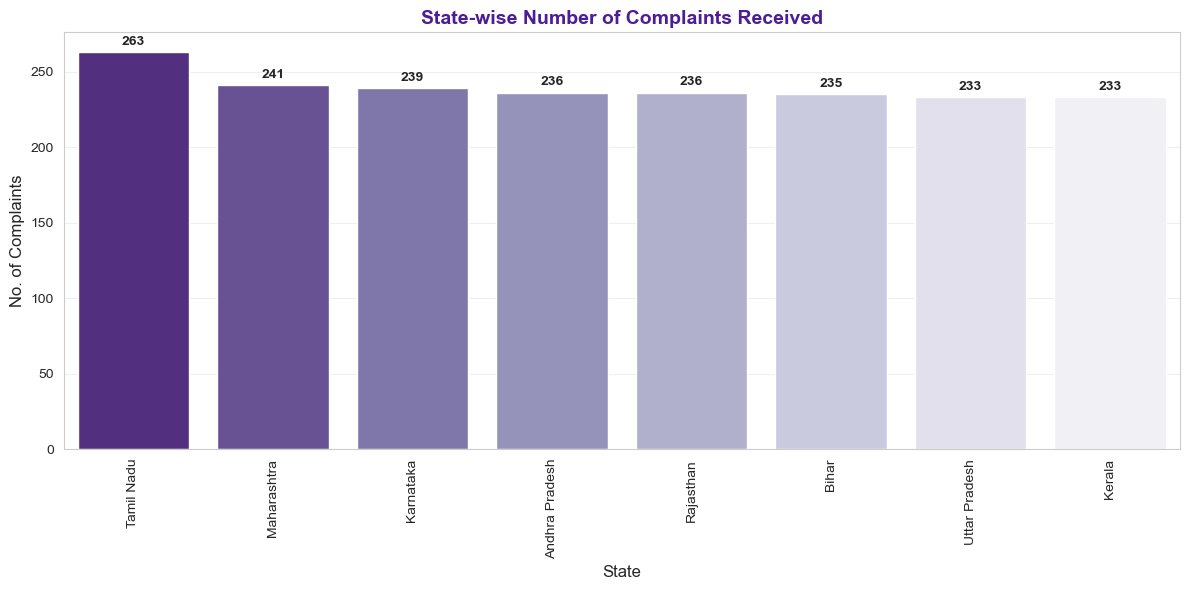

Most Complaint State: Tamil Nadu - 263 complaints


In [50]:
# Bar plot
plt.figure(figsize=(12,6))
 
complaint_state = df['State'].value_counts().reset_index()
complaint_state.columns = ['State', 'Complaint_Count']

sns.barplot(x='State', y='Complaint_Count', data=complaint_state, palette='Purples_r',hue='State',legend=False, order=complaint_state['State'])

plt.title('State-wise Number of Complaints Received', fontweight='bold', fontsize=14, color='#4C1D95')
plt.xlabel('State', fontsize=12)
plt.ylabel('No. of Complaints', fontsize=12)
plt.xticks(rotation=90)

# Top value label
for i, v in enumerate(complaint_state['Complaint_Count']):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most Complaint State: {complaint_state.iloc[0]['State']} - {complaint_state.iloc[0]['Complaint_Count']} complaints")

#### Insight: The bar chart shows the state-wise distribution of complaints received under Social Audit. Tamil Nadu has the highest number of complaints with 263, followed by Maharashtra (241) and Karnataka (239). The lowest complaints are from Kerala and Uttar Pradesh with 233 each. All 8 states have a similar range (233-263), indicating that social audit issues are almost uniformly reported across states, but Tamil Nadu needs more focus on compliance and monitoring.

### Top Mandays  VS State 

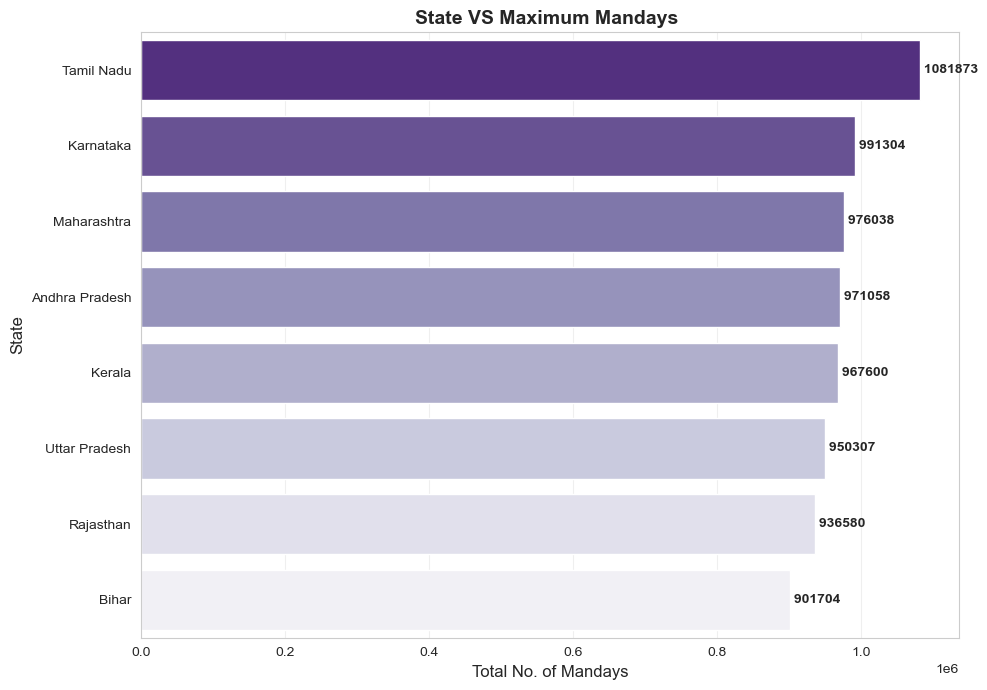

        State  Man_Days_Generated
0  Tamil Nadu             1081873


In [53]:
#Horizontal sorted bar chart

plt.figure(figsize=(10,7))
sns.barplot(x='Man_Days_Generated', y='State', data=state_mandays,hue='State',legend=False, palette='Purples_r')

plt.title('State VS Maximum Mandays ', fontweight='bold', fontsize=14)
plt.xlabel('Total No. of Mandays', fontsize=12)
plt.ylabel('State', fontsize=12)

# Value label
for i, v in enumerate(state_mandays['Man_Days_Generated']):
    plt.text(v, i, f' {int(v)}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(state_mandays.head(1)) 

#### Insight: Tamil Nadu has generated the maximum man-days of 10,81,873, followed by Karnataka (9,91,304) and Maharashtra (9,76,038). The lowest is Bihar with 9,01,704. The difference between top and bottom is less than 2 lakhs, showing balanced employment generation across all 8 states, with Tamil Nadu leading.

 ### Highest Material Cost VS work 

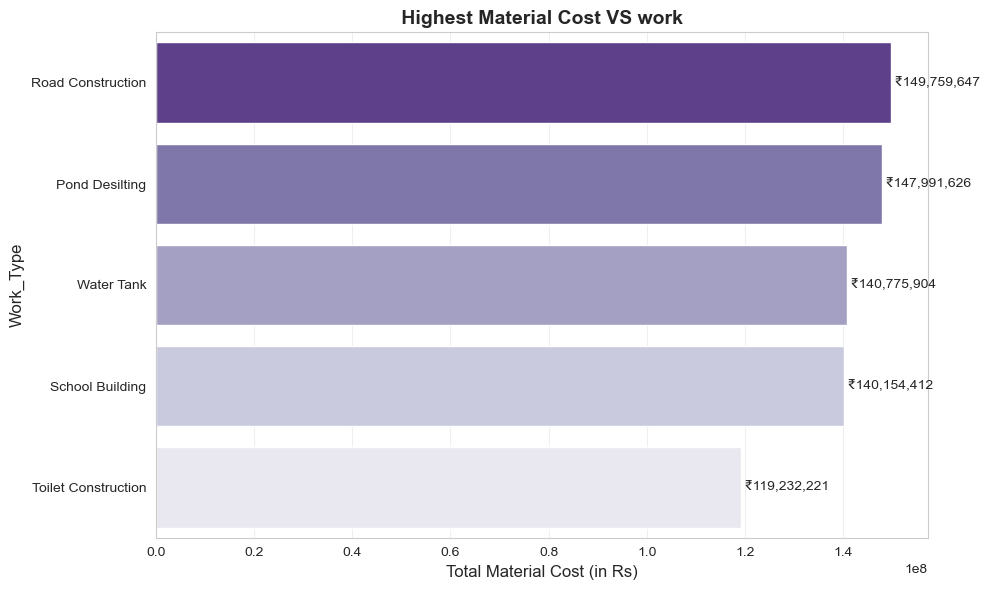

           Work_Type  Material_Cost
0  Road Construction   1.497596e+08


In [52]:
# Sorted Bar chart

work_material = df.groupby('Work_Type')['Material_Cost'].sum().sort_values(ascending=False).reset_index()


plt.figure(figsize=(10,6))
sns.barplot(x='Material_Cost', y='Work_Type', data=work_material,hue='Work_Type',legend=False, palette='Purples_r')

plt.title(' Highest Material Cost VS work ', fontweight='bold', fontsize=14)
plt.xlabel('Total Material Cost (in Rs)', fontsize=12)
plt.ylabel('Work_Type', fontsize=12)

for i, v in enumerate(work_material['Material_Cost']):
    plt.text(v, i, f' ₹{int(v):,}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(work_material.head(1)) 

#### Insight: The chart shows the highest material cost by type of work. Road Construction has the highest material cost of ₹14.97 Crores (₹149,759,647), followed closely by Pond Desilting with ₹14.79 Crores. Water Tank and School Building are around ₹14.0 Crores each. Toilet Construction has the lowest material cost among the top 5 with ₹11.92 Crores. This shows that infrastructure works like Roads and Ponds are more material-intensive and require higher budget allocation.
  #### road construction needs cement, gravel, bitumen, steel - so material component is very high compared to other works. Toilet construction is lower because it is small-scale structure and less materials needed.

### Finacial Year VS Total  State Expenditure 

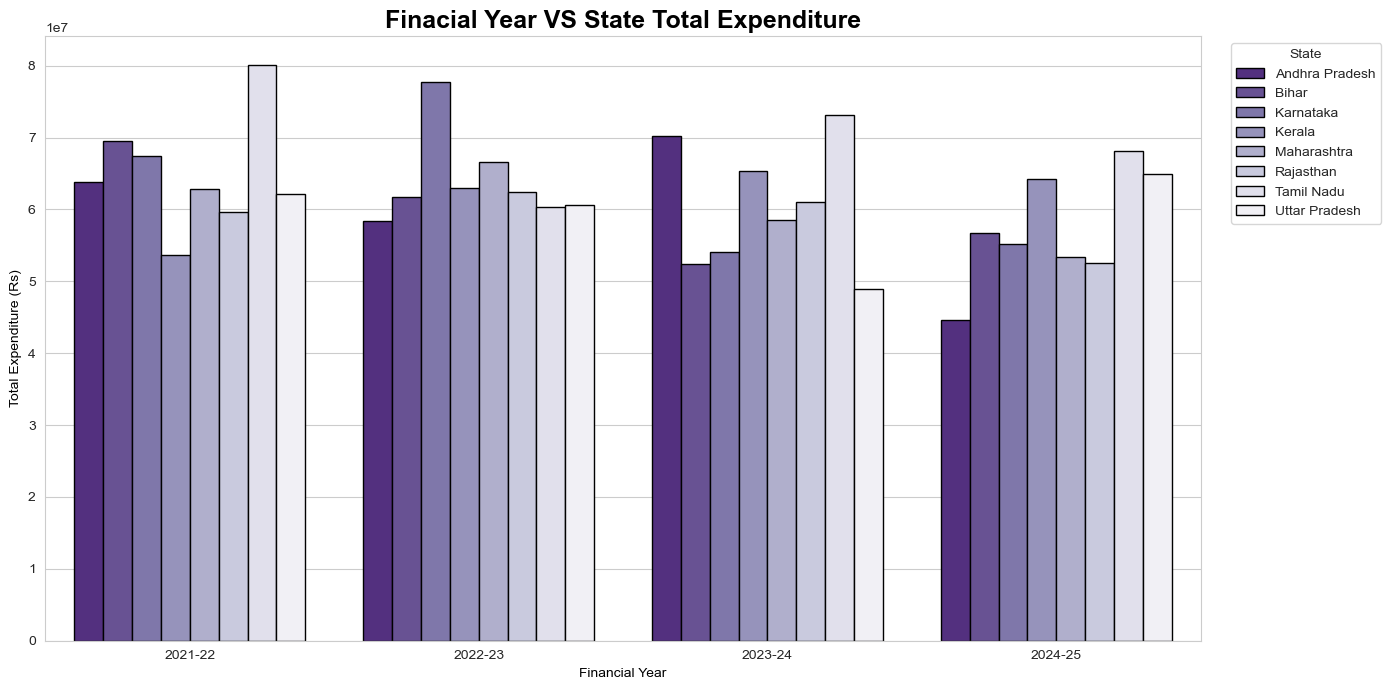

In [37]:

plt.style.use('default')
sns.set_style("whitegrid")

# Fix: 8 states = 8 colors - light purples
purples = sns.color_palette("Purples_r", 8)

plt.figure(figsize=(14,7))
sns.barplot(
    data=year_state_exp, 
    x='Financial_Year', 
    y='Total_Expenditure', 
    hue='State',
    palette=purples,
    edgecolor='black'
)
plt.title('Financial Year VS State Total Expenditure', fontsize=18, fontweight='bold', color='black')
plt.xlabel('Financial Year', color='black')
plt.ylabel('Total Expenditure (Rs)', color='black')
plt.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Insight:Year-wise State Total Expenditure

1. Tamil Nadu Dominated 2021-22:
In 2021-22, Tamil Nadu recorded the highest expenditure (∼8 Cr),followed by Bihar(~6.9 Cr) indicating intensive MGNREGA works post-pandemic recovery phase.

2. Balanced Allocation in 2022-23:
2022-23 shows a balanced fund distribution across all 8 states (~5.8 to 6.4 Cr), with Karnataka(~7.8 Cr) leading slightly. This reflects balanced fund allocation.

3. Surge in Andhra Pradesh & Tamil Nadu in 2023-24:
2023-24 witnessed a surge in Tamil Nadu(~7.4 Cr) and Andhra Pradesh (∼7 Cr), driven by increased Road and Pond construction works.

4. Overall Decline in 2024-25:
A clear decline in total expenditure is observed in 2024-25 (~4.5 to 6.8 Cr), suggesting better fund optimization and stricter social audit implementation.

5. Fluctuating Trend in Uttar Pradesh:
Uttar Pradesh shows an irregular trend - stable in 2021-23 (∼6.2 Cr), lowest in 2023-24 (∼4.8 Cr), and again highest in 2024-25 (∼6.5 Cr), indicating inconsistent fund utilization.

### Work type Trends on different States

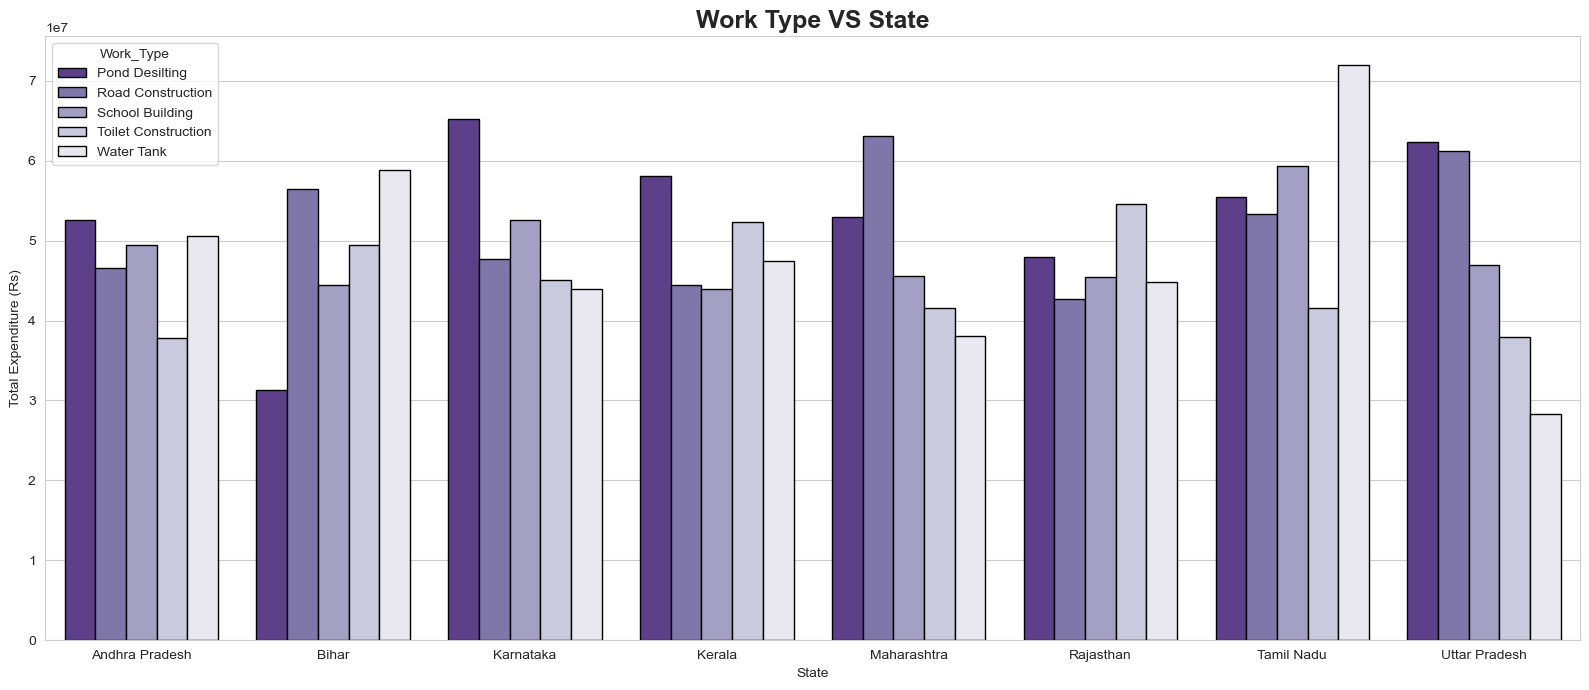

In [47]:
work_state_exp = df.groupby(['State', 'Work_Type'])['Total_Expenditure'].sum().reset_index()

plt.figure(figsize=(16,7))
sns.barplot(data=work_state_exp, x='State', y='Total_Expenditure', hue='Work_Type', palette=purples, edgecolor='black')
plt.title('Work Type VS State',fontsize=18, fontweight='bold')
plt.ylabel('Total Expenditure (Cr)')
plt.xticks(rotation=360)
plt.tight_layout()
plt.savefig('worktype_vs_state.png', dpi=300, bbox_inches='tight')
plt.show()

 Insights - Work Type vs State

1. Pond Desilting Dominates in 3 States:
Pond Desilting has highest expenditure in Uthar Pradesh (∼6.3 Cr), Karnataka (∼6.6 Cr) and Kerala (∼5.8 Cr) - shows focus on water conservation works in South India.

2. Tamil Nadu Focused on Water Tanks:
Tamil Nadu spent highest on Water Tank construction (∼7.4 Cr), which is the single highest bar in the entire chart. Lowest on Toilet Construction (∼4.2 Cr) in TN.

3. Bihar and Rajasthan Different Priority:
Bihar spent highest on Water Tank (∼5.8 Cr) and Road Construction (∼5.6 Cr), but lowest on Pond Desilting (∼3.1 Cr). Rajasthan spent highest on Toilet Construction (∼5.5 Cr).

4. Maharashtra Highest in School Building:
Maharashtra recorded highest expenditure on Road Construction (∼6.2 Cr) among all states, while Water Tank is lowest (∼3.9 Cr) there - indicating focus on infrastructure.

5. Uttar Pradesh Low in Sanitation Infrastructure:
Uttar Pradesh spent highest on Pond Desilting (∼6.2 Cr) and Road Construction (∼6.1 Cr), but lowest on Water Tank (∼2.8 Cr) and Toilet Construction (∼3.8 Cr), showing less focus on sanitation works.

<h2 style="text-align:center;font-weight:bold;color:#4C1D95;"> PHASE 3 : Insight Generation and Report </h2>
 


### SUGGESTIONS AND RECOMMENDATIONS

1. Immediate Action on PMAY-G Scheme: PMAY-G has the highest total misappropriation of ₹2.95 Crores, which is 21.9% higher than SBM-G. Since this scheme involves material procurement like cement, steel, and bricks, implement mandatory geo-tagged material bills with third-party verification. Make 100% social audit compulsory for PMAY-G to control misappropriation.

2. Fix the Pending Audit status: 60.9% of audits are still pending - Under Review 21.1%, ATR Pending 20.9%, and Pending Recovery 19.1%. Only 39% are closed or completed. Introduce a strict 30-day deadline for Action Taken Report submission with auto-redirection to BDO and District Collector. 

3. Equal Audit for All Work Sizes: Correlation between Total Expenditure and Misappropriation is only 0.01, meaning fraud does not depend on budget size. A small work of ₹50,000 can have ₹1.4 Lakhs fraud while a large work of ₹20 Lakhs can have zero fraud. Avoid concentration of auditing only high-budget works and implement random sampling audit for all sizes.

4. Strengthen Recovery Mechanism: Misappropriation vs Pending Recovery has a strong positive correlation of 0.88, and Recovery vs Pending has a negative correlation of -0.46. To improve recovery, link pending recovery with the next fund release for the Gram Panchayat. Apply the rule of no recovery, no next installment to enforce accountability.

5. Focus on High Material Cost Works and Replicate Best Practices: Road Construction has the highest material cost of ₹14.97 Crores and Pond Desilting ₹14.79 Crores, making them high-risk for misappropriation. Prioritize audits on these infrastructure works with strict physical measurement verification. Study Tamil Nadu's model which generates highest mandays of 10.8 Lakhs while maintaining uniform complaints, and replicate it in low-mandays states like Bihar at 9.01 Lakhs.



### CONCLUSION

Analysis of social audit records under MGNREGA and allied schemes identifies expenditure patterns, misappropriation trends, scheme-wise vulnerabilities, state-wise fraud distribution, and audit status gaps also shows that the social audit system is effective in detection but weak in closure. Strengthening recovery, ensuring timely audit closure, and focusing on material-intensive works like Roads and Ponds will improve the mandays for workers and impact on economic growth of states.